# Weisfeiler-Lehman Optimal Assignment Kernel + SVM (k-fold CV)

We load MUTAG, compute the **Weisfeiler-Lehman Optimal Assignment (WLOA)** kernel matrix, then run k-fold cross-validation with an SVM on that precomputed kernel.

The WLOA kernel :cite:`kriege2016valid` applies Weisfeiler-Lehman relabeling and measures the optimal assignment distance between each iteration's label histograms. It is more expressive than the standard WL subtree kernel.

## 1. Imports

In [1]:
import numpy as np

from grakel.datasets import fetch_dataset
from grakel.kernels import WeisfeilerLehmanOptimalAssignment
from grakel.utils import cross_validate_Kfold_SVM

# For the k-NN cross-validation below
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 2. Load MUTAG

`fetch_dataset` downloads (once) and parses the TU Dortmund collection. MUTAG: 188 molecular graphs labelled by mutagenicity. We keep the graphs `G` and the labels `y`.

In [2]:
mutag = fetch_dataset("MUTAG", verbose=True)
G, y = mutag.data, mutag.target
print("\n")
print("Number of graphs:", len(G))
# MUTAG labels are {-1, 1}; np.bincount requires non-negative values,
# so count via np.unique which works for any integer labels.
classes, counts = np.unique(y, return_counts=True)
print("Class distribution:", dict(zip(classes.tolist(), counts.tolist())))
print("Sample graph (adjacency, node_labels, edge_labels):")
print(G[0])

Extracting dataset  MUTAG..
Parsing dataset  MUTAG..
Parse was succesful..
Deleting unzipped dataset files..
Going back to the original directory..


Number of graphs: 188
Class distribution: {-1: 63, 1: 125}
Sample graph (adjacency, node_labels, edge_labels):
[{(3, 4), (4, 3), (5, 4), (12, 13), (5, 7), (14, 13), (8, 9), (9, 8), (9, 14), (17, 15), (10, 9), (1, 6), (13, 14), (6, 5), (15, 17), (4, 5), (14, 9), (5, 6), (9, 10), (1, 2), (10, 11), (2, 1), (11, 10), (6, 1), (15, 13), (15, 16), (13, 15), (16, 15), (3, 2), (12, 11), (4, 10), (8, 7), (10, 4), (2, 3), (11, 12), (13, 12), (7, 5), (7, 8)}, {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 1, 16: 2, 17: 2}, {(2, 1): 0, (1, 2): 0, (3, 2): 0, (2, 3): 0, (4, 3): 0, (3, 4): 0, (5, 4): 0, (4, 5): 0, (6, 5): 0, (5, 6): 0, (6, 1): 0, (1, 6): 0, (7, 5): 0, (5, 7): 0, (8, 7): 0, (7, 8): 0, (9, 8): 0, (8, 9): 0, (10, 9): 0, (9, 10): 0, (10, 4): 0, (4, 10): 0, (11, 10): 0, (10, 11): 0, (12, 11): 0, 

## 3. Compute the WLOA kernel matrix

Instantiate the kernel, then `fit_transform` returns the Gram matrix `K`. `normalize=True` keeps `K` in $[0, 1]$. `n_iter` sets the number of WL relabeling steps.

**Note:** `fit_transform(G)` uses the graphs' **node labels** (node attributes) to build the kernel matrix — but it does **not** use the class labels `y`. The class labels `y` are consumed only later, for visualization (sorting) and for the SVM/k-NN classification.

In [3]:
gk = WeisfeilerLehmanOptimalAssignment(n_iter=5, normalize=True, n_jobs=-1)
K = gk.fit_transform(G)

print("Kernel matrix shape:", K.shape)

Kernel matrix shape: (188, 188)


## 3b. Visualize the kernel matrix

`K[i, j]` is the WLOA similarity between graphs `i` and `j`. We sort rows/columns by class to group identical labels together. If the kernel captures class structure, the diagonal blocks (same class) are brighter and the off-diagonal regions are darker. The white lines mark the boundary between the two MUTAG classes (`-1` and `1`).

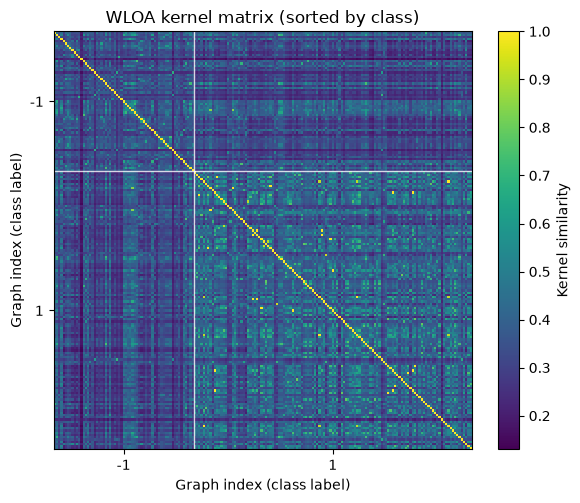

In [4]:
# Order graphs by class label so the two-class block structure becomes visible.
order = np.argsort(y)
K_ordered = K[np.ix_(order, order)]
y_ordered = y[order]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(K_ordered, cmap="viridis", interpolation="nearest")

# Class boundary lines (MUTAG labels are {-1, 1})
boundaries = np.where(np.diff(y_ordered) != 0)[0] + 0.5
for b in boundaries:
    ax.axhline(b, color="white", lw=1.0, alpha=0.8)
    ax.axvline(b, color="white", lw=1.0, alpha=0.8)

# Class labels on the axes
unique_classes = np.unique(y_ordered)
tick_positions = [np.mean(np.where(y_ordered == c)[0]) for c in unique_classes]
ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)
ax.set_xticklabels([str(int(c)) for c in unique_classes])
ax.set_yticklabels([str(int(c)) for c in unique_classes])

ax.set_title("WLOA kernel matrix (sorted by class)")
ax.set_xlabel("Graph index (class label)")
ax.set_ylabel("Graph index (class label)")
fig.colorbar(im, ax=ax, label="Kernel similarity")
plt.tight_layout()
plt.show()

## 4. k-fold cross-validation with SVM (built-in utility)

`cross_validate_Kfold_SVM` takes a *list* of precomputed kernel matrices, runs `n_iter` repetitions of `n_splits`-fold CV, and picks the SVM `C` by an inner grid search. It returns the per-iteration mean fold accuracies.

In [7]:
accs = cross_validate_Kfold_SVM([K], y, n_iter=5, n_splits=10, random_state=42)

mean_acc = np.mean(accs[0])
std_acc = np.std(accs[0])
print(f"WLOA + SVM average accuracy: {mean_acc * 100:.2f}%")
print(f"Standard deviation: {std_acc * 100:.2f}%")

WLOA + SVM average accuracy: 84.15%
Standard deviation: 2.22%


## 5. Same task, different classifier (kernel k-NN)

GraKeL kernels are plain scikit-learn transformers, so they feed **any** estimator that takes a precomputed kernel/distance matrix, not just SVMs. 

Same MUTAG task, now with a **kernel k-Nearest-Neighbours** classifier. The WLOA kernel outputs a *similarity* matrix `K`; `KNeighborsClassifier(metric="precomputed")` wants a *distance* matrix, so we use `1 - K` (valid because `normalize=True` keeps `K` in $[0, 1]$). The whole thing is a `Pipeline` evaluated with scikit-learn's own `cross_validate`.

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import cross_validate

# GraKeL kernel -> distance conversion -> k-NN, all sklearn-native.
pipe = Pipeline([
    ("wl", WeisfeilerLehmanOptimalAssignment(n_iter=5, normalize=True, n_jobs=-1)),
    ("to_distance", FunctionTransformer(func=lambda mat: 1.0 - mat)),
    ("knn", KNeighborsClassifier(n_neighbors=3, metric="precomputed")),
])

cv_results = cross_validate(
    pipe, G, y, cv=KFold(n_splits=10, shuffle=True, random_state=42)
)
knn_acc = cv_results["test_score"]
print(f"WLOA + k-NN average accuracy: {knn_acc.mean() * 100:.2f}% (+/- {knn_acc.std() * 100:.2f}%)")

WLOA + k-NN average accuracy: 85.15% (+/- 11.94%)


## 6. Summary

- `fetch_dataset("MUTAG")` loads a benchmark graph dataset.
- `WeisfeilerLehmanOptimalAssignment` produces a custom graph-kernel Gram matrix `K`.
- Since GraKeL kernels are scikit-learn transformers, `K` feeds **any** estimator that takes a precomputed kernel/distance matrix — here an SVM (`cross_validate_Kfold_SVM`) and a kernel k-NN (`KNeighborsClassifier`) on the same task.

Swap `n_iter`, `normalize`, the dataset (e.g. `ENZYMES`, `PROTEINS`), or the classifier to experiment further.